In [104]:
import requests
import numpy as np
import json
import pandas as pd
from datetime import datetime, timedelta
import sklearn
end_date = datetime(2024, 6, 1)
start_date = end_date - timedelta(days=6000)

# Design

Try with index fund

# Additional Possible Features if time allows it
look into : https://www.investopedia.com/top-7-technical-analysis-tools-4773275

In [ ]:
API_KEY = "wUvM2M29ZVxHDvK8IRp2P7iyrT8uhQG4"

ticker = "AAPL"

url_hist_stock_price = f"https://financialmodelingprep.com/stable/historical-price-eod/full?symbol={ticker}&from={start_date.date()}&to={end_date.date()}&apikey={API_KEY}"

# Historical Data Request
response_hist_stock_price = requests.get(url_hist_stock_price)

json_response_hist_stock_price = response_hist_stock_price.json()

df_stock_hist = pd.DataFrame(json_response_hist_stock_price)

df_stock_hist['date'] = pd.to_datetime(df_stock_hist['date'])
df_stock_hist['close'] = df_stock_hist['close'].astype(float)
df_stock_hist['open'] = df_stock_hist['open'].astype(float)
df_stock_hist['high'] = df_stock_hist['high'].astype(float)
df_stock_hist['low'] = df_stock_hist['low'].astype(float)


df_stock_hist.set_index('date', inplace=True)
df_stock_hist.drop(columns=['symbol'])

closing_price = df_stock_hist[['close']]

# AD LINE
denominator = df_stock_hist['high'] - df_stock_hist['low']
denominator = denominator.replace(0, np.nan)

# RESEARCH A BIT MORE
mfm = ((df_stock_hist['close'] - df_stock_hist['low']) - (df_stock_hist['high'] - df_stock_hist['close'])) / denominator
mfv_series = mfm * df_stock_hist['volume']
mfv = mfv_series.fillna(0)
mfv = mfv.to_frame(name="MFV")
ad_line = mfv['MFV'].cumsum().to_frame()
i_volume = df_stock_hist[['volume']]
volume =i_volume.apply(np.log10)


              ret_1d    ret_5d   ret_10d    vol_5d   vol_10d  momentum_10d  \
date                                                                         
2024-03-21 -0.005282 -0.000641  0.010555  0.013119  0.009809          1.79   
2024-03-20  0.042598  0.030927  0.058346  0.023394  0.016110          9.85   
2024-03-19 -0.014496  0.037535  0.037902  0.021682  0.017350          6.43   
2024-03-18 -0.013403  0.016798  0.028903  0.023659  0.018029          4.88   
2024-03-15 -0.006332  0.001974  0.015233  0.023825  0.018191          2.59   
2024-03-14  0.002201  0.009512  0.008864  0.023595  0.018034          1.52   
2024-03-13 -0.010809 -0.042201 -0.012579  0.006792  0.018037         -2.18   
2024-03-12  0.012271 -0.016186  0.020741  0.010492  0.017036          3.52   
2024-03-11 -0.002771 -0.005584  0.011121  0.008862  0.017020          1.90   
2024-03-08 -0.011693 -0.010949 -0.008997  0.009917  0.017266         -1.55   
2024-03-07 -0.010133 -0.023121 -0.013830  0.010093  0.017474   

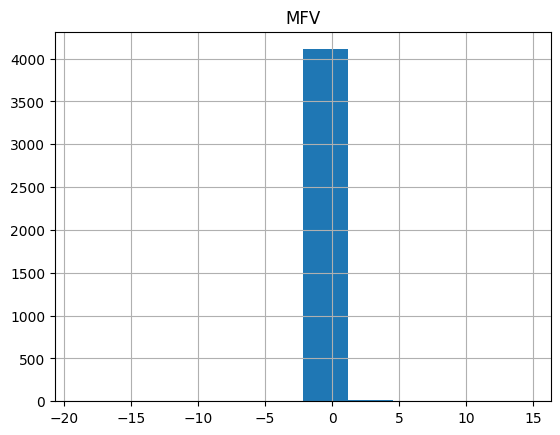

In [ ]:
# Daily Return
daily_return = closing_price.pct_change()
# 5-Day Return
ret_5d = closing_price.pct_change(5)
# 10-Day Return
ret_10d = closing_price.pct_change(10)

# 5-Day Volatility (Std Dev of Returns)
vol_5d = closing_price.pct_change().rolling(window=5).std()

# 10-Day Volatility
vol_10d = closing_price.pct_change().rolling(window=10).std()

# Momentum (10d)
momentum_10d = closing_price - closing_price.shift(10)

AD_momentum_5d = ad_line.pct_change(5)

# SMA_10/SMA_50 Ratio
sma_10 = closing_price.rolling(window=10).mean()
sma_50 = closing_price.rolling(window=50).mean()
sma_ratio = sma_10/sma_50

# Z-score (20d)
rolling_mean = closing_price.rolling(window=20).mean()
rolling_std = closing_price.rolling(window=20).std()
z_score_20d = (closing_price - rolling_mean)/rolling_std

# RSI (14d)
delta = closing_price.diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)

avg_gain = gain.rolling(window=14).mean()
avg_loss = loss.rolling(window=14).mean()

rs = avg_gain/avg_loss
rsi_14 = 100 - (100 / (1 + rs))

y = closing_price.pct_change(-30)

avrg = y.mean()

y.columns = ['y']


dataframes = [
    (daily_return, 'ret_1d'),
    (ret_5d, 'ret_5d'),
    (ret_10d, 'ret_10d'),
    (vol_5d, 'vol_5d'),
    (vol_10d, 'vol_10d'),
    (momentum_10d, 'momentum_10d'),
    (sma_ratio, 'sma_ratio_10_50'),
    (z_score_20d, 'zscore_20d'),
    (rsi_14, 'rsi_14'),
    (volume,'volume'),
    (AD_momentum_5d,'AD_momentum_5d'),
    (y,'y'),
]
AD_momentum_5d.hist()
print()
df_features_short_term = pd.concat(
    [df.rename(columns={df.columns[0]: name}) for df, name in dataframes],
    axis=1
).dropna()

print(df_features_short_term)

In [107]:
print(y.max())

y    0.464646
dtype: float64


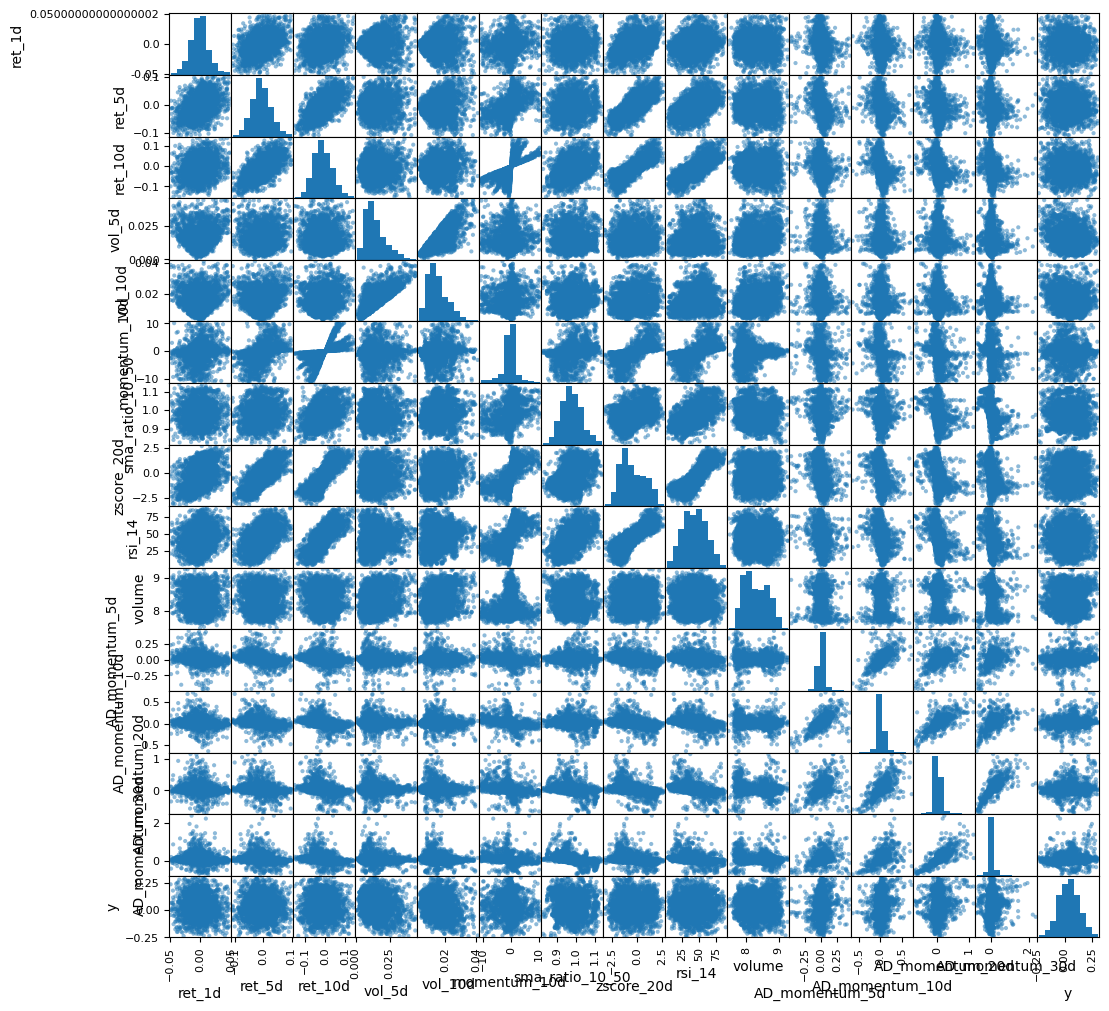

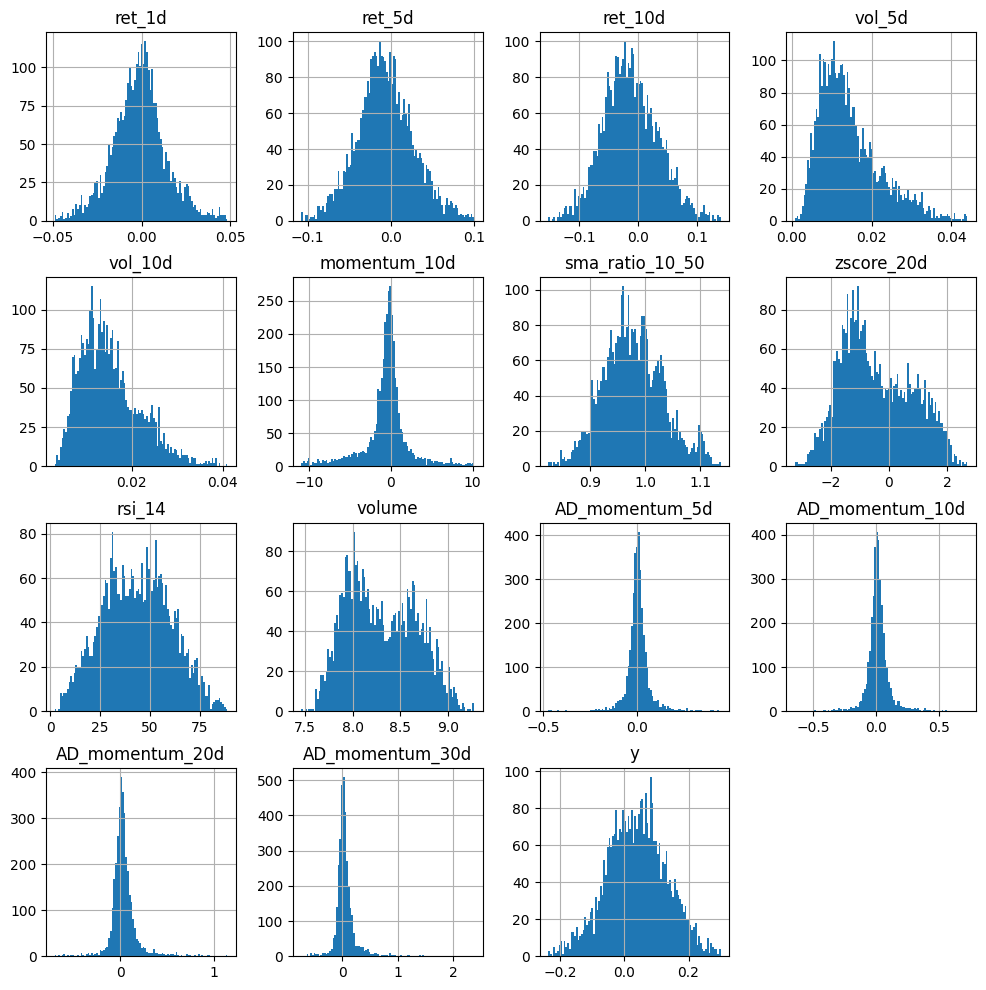

In [108]:
import numpy as np
import pandas as pd
from scipy.stats import zscore

# Calculate Z-scores for the dataset
z_scores = np.abs(zscore(df_features_short_term))

# Set a threshold for identifying outliers (commonly 3)
threshold = 2.5 # confidence interval of data around 97.6 %.

# Identify rows where any column has a Z-score greater than threshold
outliers = (z_scores > threshold).any(axis=1)

# Remove outliers
df_no_outliers = df_features_short_term[~outliers]

# DATA ANALYSIS
from pandas.plotting import scatter_matrix

scatter_matrix(df_no_outliers, figsize=(12, 12), diagonal='hist')  # or 'kde'
df_no_outliers.hist(figsize=(12, 12), bins=100)

X_data = df_no_outliers.drop(columns=['y'])
y = df_no_outliers['y']

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_data)
X_scaled = scaler.transform(X_data)
X = pd.DataFrame(X_scaled, index=X_data.index, columns=X_data.columns)


In [109]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error 

from sklearn.model_selection import TimeSeriesSplit
import numpy as np

# Sample time series data
# Split data between test set and train

import pandas as pd

# Ensure Date column is datetime type and sort the data
def train_test_split(df, ratio=0.2):

    num_instances = df.shape[0]

    split_index = int(num_instances * (1 - ratio))
    train_df = df.iloc[:split_index]
    test_df = df.iloc[split_index:]
    return (train_df,test_df)

X_train, X_test = train_test_split(X)
y_train, y_test = train_test_split(y)



# Use Kfold validation to tune hyperparameters using the train dataset
X_train_arr = X_train.values
y_train_arr = y_train.values

tscv = TimeSeriesSplit(n_splits=5)

val_rmse_scores = []
for i, (train_index, val_index) in enumerate(tscv.split(X_train_arr)):
    print(f"Split {i+1}: Train {len(train_index)}, Test {len(val_index)}")

    X_train_i, X_val_i = X_train_arr[train_index], X_train_arr[val_index]
    y_train_i, y_val_i = y_train_arr[train_index], y_train_arr[val_index]

    model = xgb.XGBRegressor(n_estimators=1000, 
                             early_stopping_rounds=50, 
                             learning_rate=0.01)

    model.fit(
        X_train_i, y_train_i,
        eval_set=[(X_train_i,y_train_i),(X_val_i, y_val_i)],
        verbose=100
    )
    
    preds = model.predict(X_val_i)
    rmse = root_mean_squared_error(y_val_i, preds)
    val_rmse_scores.append(rmse)

# Have a metric for directional accuracy to evaluate the impact of different hyperparameters
print(val_rmse_scores)
final_rmse = np.mean(val_rmse_scores)
print(f"\nFinal average RMSE across all folds: {final_rmse:.4f}")



model = xgb.XGBRegressor(n_estimators=1000,early_stopping_rounds=50,learning_rate=0.01)

model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=100) # not sure about this

final_pred = model.predict(X_test)

print(root_mean_squared_error(y_test, final_pred))


Split 1: Train 462, Test 462
[0]	validation_0-rmse:0.09036	validation_1-rmse:0.10888
[50]	validation_0-rmse:0.06755	validation_1-rmse:0.11645
Split 2: Train 924, Test 462
[0]	validation_0-rmse:0.09721	validation_1-rmse:0.08772
[50]	validation_0-rmse:0.08022	validation_1-rmse:0.09040
Split 3: Train 1386, Test 462
[0]	validation_0-rmse:0.09400	validation_1-rmse:0.09040
[100]	validation_0-rmse:0.07073	validation_1-rmse:0.08670
[200]	validation_0-rmse:0.05817	validation_1-rmse:0.08561
[253]	validation_0-rmse:0.05302	validation_1-rmse:0.08572
Split 4: Train 1848, Test 462
[0]	validation_0-rmse:0.09282	validation_1-rmse:0.07362
[49]	validation_0-rmse:0.08011	validation_1-rmse:0.07688
Split 5: Train 2310, Test 462
[0]	validation_0-rmse:0.08921	validation_1-rmse:0.11074
[72]	validation_0-rmse:0.07506	validation_1-rmse:0.11052
[0.10888320221433025, 0.08771741126966119, 0.08556918872395451, 0.0736175345017306, 0.10993688484717665]

Final average RMSE across all folds: 0.0931
[0]	validation_0-rms

<Axes: title={'center': 'Feature Importance'}>

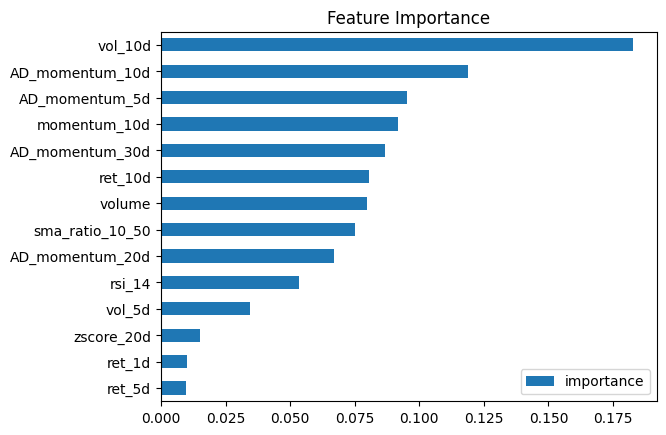

In [110]:
fi = pd.DataFrame(data = model.feature_importances_,index=model.feature_names_in_,columns=['importance'])
fi.sort_values('importance').plot(kind='barh',title='Feature Importance')


In [111]:
y_pred = model.predict(X_test)
pd.set_option('display.max_rows', None)
result = pd.DataFrame()
result['y'] = y_test
result['y_pred'] = y_pred
result['diff'] = y_test-y_pred
result['sign'] = np.sign(result['y']) == np.sign(result['y_pred'])
print(result)
same_sign = (result['sign']).sum()
print(result['diff'].mean())
print(same_sign/len(y_pred))

                   y    y_pred      diff   sign
date                                           
2011-07-18  0.088020  0.034386  0.053634   True
2011-07-15  0.054207  0.034386  0.019821   True
2011-07-14  0.035656  0.032183  0.003473   True
2011-07-13  0.029791  0.032183 -0.002393   True
2011-07-12  0.048133  0.032183  0.015949   True
2011-07-11  0.056856  0.031165  0.025691   True
2011-07-08  0.068163  0.032645  0.035518   True
2011-07-07  0.075885  0.032183  0.043702   True
2011-07-06  0.051926  0.032183  0.019743   True
2011-07-05  0.042607  0.033479  0.009128   True
2011-07-01  0.008224  0.032183 -0.023960   True
2011-06-30 -0.012356  0.033479 -0.045834  False
2011-06-29 -0.005833  0.033714 -0.039548  False
2011-06-28  0.005882  0.033901 -0.028019   True
2011-06-27 -0.024671  0.033714 -0.058385  False
2011-06-24 -0.058158  0.032183 -0.090342  False
2011-06-23 -0.045968  0.032183 -0.078151  False
2011-06-22 -0.076923  0.032645 -0.109568  False
2011-06-21 -0.063658  0.032183 -0.095842